# 05 — 2D Segmentation with SAM3

In this notebook, similar to the previous one, we will focus on the segmentation stage of the pipeline, but this time we will evaluate the performance of **SAM3** for segmenting and tracking parts of a subject across the video frames.

### In this notebook, we will:

1. **RGB stream sanity check**
   - Load the `.vrs` file with `projectaria_tools`.
   - Validate RGB stream access and timestamp consistency.

2. **Frames conversion to 5fps and prompt initialization**
   - Downsample the original 30fps frames to 5fps for efficient SAM3 inference.
   - Select only a few clean frames to initialize prompts.

3. **SAM3 baseline segmentation**
   - Multi-object prompting (beard and hands).
   - Mask propagation across time.

4. **Failure analysis and diagnostics**
   - Inspect drift, mask merging, holes, and missing thin parts.
   - Produce visual overlays for qualitative review.

5. **Quantitative temporal metrics**
   - Mask area stability, centroid jitter, continuity/drop rate.

As a sample, we will use `gnome_bright.vrs` located in the local `data/raw/gnome_bright/` directory.

For this notebook, we used as references:
* SAM3: https://github.com/facebookresearch/sam3

## 5.1 RGB Stream Sanity Check

In this section, we validate RGB stream access, timestamps, and frame decoding for `gnome_bright.vrs`. 

In [1]:
import os
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from projectaria_tools.core import data_provider, sensor_data

In [2]:
# Paths and basic validation
VRS_PATH = os.path.join("..", "data", "raw", "gnome_bright", "gnome_bright.vrs")
OUT_ROOT = os.path.join("..", "data", "outputs", "segmentation", "gnome")
Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

if not os.path.exists(VRS_PATH):
    raise FileNotFoundError(f"VRS file not found: {os.path.abspath(VRS_PATH)}")

print("VRS path:", os.path.abspath(VRS_PATH))
print("Output root:", os.path.abspath(OUT_ROOT))

# Make project helpers importable
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
project_root = next((p for p in candidates if (p / "scripts" / "aria_dataset.py").exists()), None)
if project_root is None:
    raise RuntimeError(f"Cannot find scripts/aria_dataset.py from cwd={cwd}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts.aria_dataset import _extract_image_array_from_sample

VRS path: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\gnome_bright\gnome_bright.vrs
Output root: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\gnome


In [3]:
# Helper functions for VRS access and RGB stream handling
def create_provider(vrs_path: str):
    provider = data_provider.create_vrs_data_provider(vrs_path)
    if provider is None:
        raise RuntimeError("Failed to create VRS data provider.")
    return provider

# Attempt to find the RGB stream by preferred ID, then by label heuristics
def resolve_rgb_stream(provider, preferred_stream_id_str: str = "214-1"):
    candidates = [sid for sid in provider.get_all_streams() if str(sid) == preferred_stream_id_str]
    if len(candidates) > 0:
        stream_id = candidates[0]
        return provider.get_label_from_stream_id(stream_id), stream_id, provider.get_num_data(stream_id)

    for stream_id in provider.get_all_streams():
        label = str(provider.get_label_from_stream_id(stream_id)).lower()
        if "rgb" in label:
            return provider.get_label_from_stream_id(stream_id), stream_id, provider.get_num_data(stream_id)

    raise RuntimeError("No RGB stream found in VRS.")

# Retrieve RGB timestamps in nanoseconds for a given stream and sample count
def get_rgb_timestamps_ns(provider, stream_id, sample_count):
    timestamps = np.empty(sample_count, dtype=np.int64)
    for i in range(sample_count):
        sample = provider.get_sensor_data_by_index(stream_id, i)
        timestamps[i] = sample.get_time_ns(sensor_data.TimeDomain.DEVICE_TIME)
    return timestamps

# Retrieve RGB frame as a numpy array for a given stream and sample index
def get_rgb_frame_by_index(provider, stream_id, index: int):
    sample = provider.get_sensor_data_by_index(stream_id, int(index))
    return _extract_image_array_from_sample(sample)

RGB stream label: camera-rgb
RGB stream id: 214-1
RGB sample count: 4028
Duration: 134.21 s


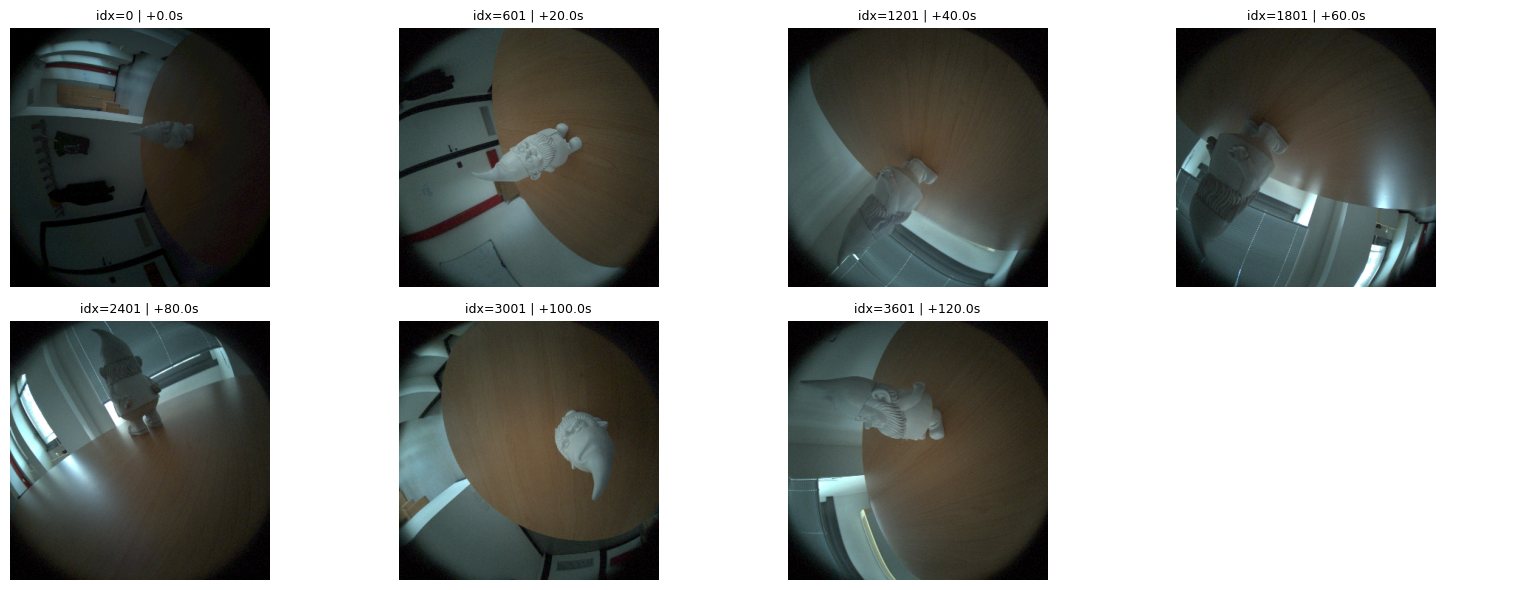

In [ ]:
provider = create_provider(VRS_PATH)
rgb_label, rgb_stream_id, rgb_sample_count = resolve_rgb_stream(provider)
rgb_timestamps_ns = get_rgb_timestamps_ns(provider, rgb_stream_id, rgb_sample_count)

print("RGB stream label:", rgb_label)
print("RGB stream id:", rgb_stream_id)
print("RGB sample count:", rgb_sample_count)

base_ts_ns = int(rgb_timestamps_ns[0])
last_ts_ns = int(rgb_timestamps_ns[-1])
duration_s = (last_ts_ns - base_ts_ns) / 1e9
print(f"Duration: {duration_s:.2f} s")

# Display one frame every 40 seconds as a sanity check
step_s = 40
target_offsets_s = list(range(0, int(duration_s) + 1, step_s))

sample_indices = []
for off_s in target_offsets_s:
    target_ts_ns = base_ts_ns + int(off_s * 1e9)
    idx = int(np.searchsorted(rgb_timestamps_ns, target_ts_ns, side="left"))
    if idx >= rgb_sample_count:
        idx = rgb_sample_count - 1
    sample_indices.append(idx)

# Deduplicate while preserving order
seen = set()
sample_indices = [i for i in sample_indices if not (i in seen or seen.add(i))]

downsample = 4
ncols = 4
nrows = (len(sample_indices) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

for k in range(nrows * ncols):
    ax = axes.flat[k]
    ax.axis("off")
    if k >= len(sample_indices):
        continue

    idx = sample_indices[k]
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    frame_small = frame_rgb[::downsample, ::downsample]
    rel_s = (int(rgb_timestamps_ns[idx]) - base_ts_ns) / 1e9

    ax.imshow(frame_small)
    ax.set_title(f"idx={idx} | +{rel_s:.1f}s", fontsize=9)

plt.tight_layout()
plt.show()

## 5.2 Frames Conversion to 5fps and Prompt Initialization

In this section, we convert the original 30fps frames to 5fps for efficient SAM3 inference.

We also inspect a few candidate frames and choose a clean prompt frame for the initial segmentation.

In [5]:
import shutil
from PIL import Image
import matplotlib.patches as patches

# Output directories
SAM3_ROOT = Path(OUT_ROOT) / "sam3"
SAM3_FRAMES_DIR = SAM3_ROOT / "frames"
SAM3_FRAMES_DIR_5FPS = SAM3_ROOT / "frames_5fps"

SAM3_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
SAM3_FRAMES_DIR_5FPS.mkdir(parents=True, exist_ok=True)

print("SAM3 root:", SAM3_ROOT)
print("Frames dir:", SAM3_FRAMES_DIR)
print("5fps frames dir:", SAM3_FRAMES_DIR_5FPS)

SAM3 root: ..\data\outputs\segmentation\gnome\sam3
Frames dir: ..\data\outputs\segmentation\gnome\sam3\frames
5fps frames dir: ..\data\outputs\segmentation\gnome\sam3\frames_5fps


In [6]:
# 5.2.1 Exports RGB frames to disk with caching and optional force rebuild
def export_rgb_frames(
    provider,
    stream_id,
    sample_count: int,
    out_dir: Path,
    ext: str = "jpg",
    jpg_quality: int = 95,
    force_rebuild: bool = False,
):
    out_dir.mkdir(parents=True, exist_ok=True)
    ext = ext.lower().lstrip(".")

    expected_files = [out_dir / f"{i:06d}.{ext}" for i in range(sample_count)]
    cache_complete = all(p.exists() for p in expected_files)

    if cache_complete and not force_rebuild:
        print(f"Frame cache already complete. Skipping export: {out_dir}")
        return

    if force_rebuild:
        for p in out_dir.glob(f"*.{ext}"):
            p.unlink()

    for i in range(sample_count):
        out_path = out_dir / f"{i:06d}.{ext}"
        if out_path.exists() and not force_rebuild:
            continue

        frame_rgb = get_rgb_frame_by_index(provider, stream_id, i)
        Image.fromarray(frame_rgb).save(out_path, quality=jpg_quality, subsampling=0, optimize=True)

    print(f"Export completed: {out_dir} ({sample_count} frames, .{ext})")

In [7]:
# 5.2.2 Export full 30fps RGB sequence to disk
export_rgb_frames(
    provider=provider,
    stream_id=rgb_stream_id,
    sample_count=rgb_sample_count,
    out_dir=SAM3_FRAMES_DIR,
    ext="jpg",
    jpg_quality=95,
    force_rebuild=False,
)

Frame cache already complete. Skipping export: ..\data\outputs\segmentation\gnome\sam3\frames


In [8]:
# 5.2.3 Convert exported frames to 5fps with caching and optional force rebuild
def convert_frames_to_5fps(
    frames_dir: Path,
    out_dir: Path,
    original_fps: int = 30,
    target_fps: int = 5,
    ext: str = "jpg",
    force_rebuild: bool = False,
):
    out_dir.mkdir(parents=True, exist_ok=True)
    ext = ext.lower().lstrip(".")

    frame_files = sorted(frames_dir.glob(f"*.{ext}"))
    if len(frame_files) == 0:
        raise RuntimeError(f"No frames found in {frames_dir} with extension .{ext}")

    step = int(round(original_fps / target_fps))
    if step <= 0:
        raise ValueError("Invalid fps ratio")

    selected_files = frame_files[::step]

    expected_files = [out_dir / f"{i:06d}.{ext}" for i in range(len(selected_files))]
    cache_complete = all(p.exists() for p in expected_files)

    if cache_complete and not force_rebuild:
        print(f"5fps cache already complete. Skipping conversion: {out_dir}")
        print(f"Frames already available: {len(selected_files)}")
        return

    if force_rebuild:
        for p in out_dir.glob(f"*.{ext}"):
            p.unlink()

    for i, src_path in enumerate(selected_files):
        dst_path = out_dir / f"{i:06d}.{ext}"
        if dst_path.exists() and not force_rebuild:
            continue
        shutil.copy2(src_path, dst_path)

    print(f"Converted {len(frame_files)} -> {len(selected_files)} frames in {out_dir}")

In [9]:
convert_frames_to_5fps(
    frames_dir=SAM3_FRAMES_DIR,
    out_dir=SAM3_FRAMES_DIR_5FPS,
    original_fps=30,
    target_fps=5,
    ext="jpg",
    force_rebuild=False,
)

5fps cache already complete. Skipping conversion: ..\data\outputs\segmentation\gnome\sam3\frames_5fps
Frames already available: 672


### 5.2.4 Prompt Initialization

We use fixed prompt frames (already in the 5fps timeline):
- Frame 120: hat and eyes
- Frame 375: right hand

No 30fps-to-5fps index conversion is needed for these prompts as it was already done.

In [10]:
# Fixed prompt frames in the 5fps timeline (no conversion needed)
frame_files_5fps = sorted(SAM3_FRAMES_DIR_5FPS.glob("*.jpg"))
if len(frame_files_5fps) == 0:
    raise RuntimeError(f"No JPG frames found in: {SAM3_FRAMES_DIR_5FPS}")

PROMPT_FRAME_IDX_BY_OBJECT = {
    "hat": 120,
    "eyes": 120,
    "right_hand": 375,
}

# Validate indices
max_idx = len(frame_files_5fps) - 1
for obj_name, idx in PROMPT_FRAME_IDX_BY_OBJECT.items():
    if idx < 0 or idx > max_idx:
        raise ValueError(
            f"Prompt index out of range for {obj_name}: {idx} (valid: 0..{max_idx})"
        )

print("5fps frame count:", len(frame_files_5fps))
print("Prompt frames:", PROMPT_FRAME_IDX_BY_OBJECT)

5fps frame count: 672
Prompt frames: {'hat': 120, 'eyes': 120, 'right_hand': 375}


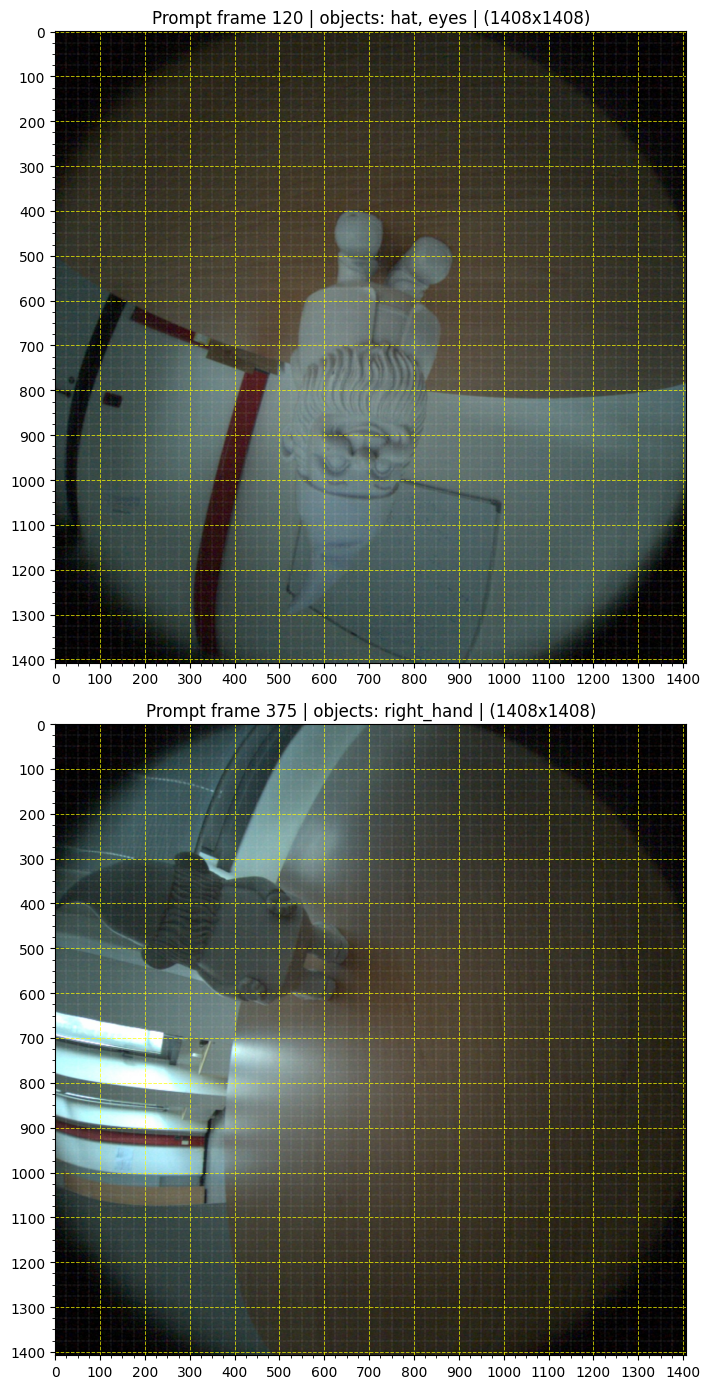

In [11]:
# Detailed visual check of fixed prompt frames (full view only, dense grid)
fixed_prompt_frames = sorted(set(PROMPT_FRAME_IDX_BY_OBJECT.values()))

nrows = len(fixed_prompt_frames)
ncols = 1

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 7 * nrows))
if nrows == 1:
    axes = [axes]

for r, idx in enumerate(fixed_prompt_frames):
    frame_rgb = np.array(Image.open(frame_files_5fps[idx]).convert("RGB"))
    h, w = frame_rgb.shape[:2]

    objs_here = [name for name, fidx in PROMPT_FRAME_IDX_BY_OBJECT.items() if fidx == idx]
    title_base = f"Prompt frame {idx} | objects: {', '.join(objs_here)} | ({w}x{h})"

    ax = axes[r]
    ax.imshow(frame_rgb)
    ax.set_title(title_base, fontsize=12)
    ax.axis("on")

    # Major grid every 100 px
    ax.set_xticks(np.arange(0, w + 1, 100))
    ax.set_yticks(np.arange(0, h + 1, 100))

    # Minor grid every 25 px
    ax.set_xticks(np.arange(0, w + 1, 25), minor=True)
    ax.set_yticks(np.arange(0, h + 1, 25), minor=True)

    ax.grid(which="major", color="yellow", linestyle="--", linewidth=0.7, alpha=0.7)
    ax.grid(which="minor", color="white", linestyle=":", linewidth=0.35, alpha=0.45)

plt.tight_layout()
plt.show()

In [12]:
# Prompt boxes in 5fps coordinates: [x0, y0, x1, y1]
BOX_PROMPTS_5FPS = {
    "eyes": [600, 950, 750, 1000],
    "hat": [500, 975, 750, 1300],
    "right_hand": [475, 375, 550, 425],
}

# Object IDs used later during SAM3 prompting
OBJECT_IDS = {
    "eyes": 1,
    "hat": 2,
    "right_hand": 3,
}

print("BOX_PROMPTS_5FPS:", BOX_PROMPTS_5FPS)
print("OBJECT_IDS:", OBJECT_IDS)

BOX_PROMPTS_5FPS: {'eyes': [600, 950, 750, 1000], 'hat': [500, 975, 750, 1300], 'right_hand': [475, 375, 550, 425]}
OBJECT_IDS: {'eyes': 1, 'hat': 2, 'right_hand': 3}


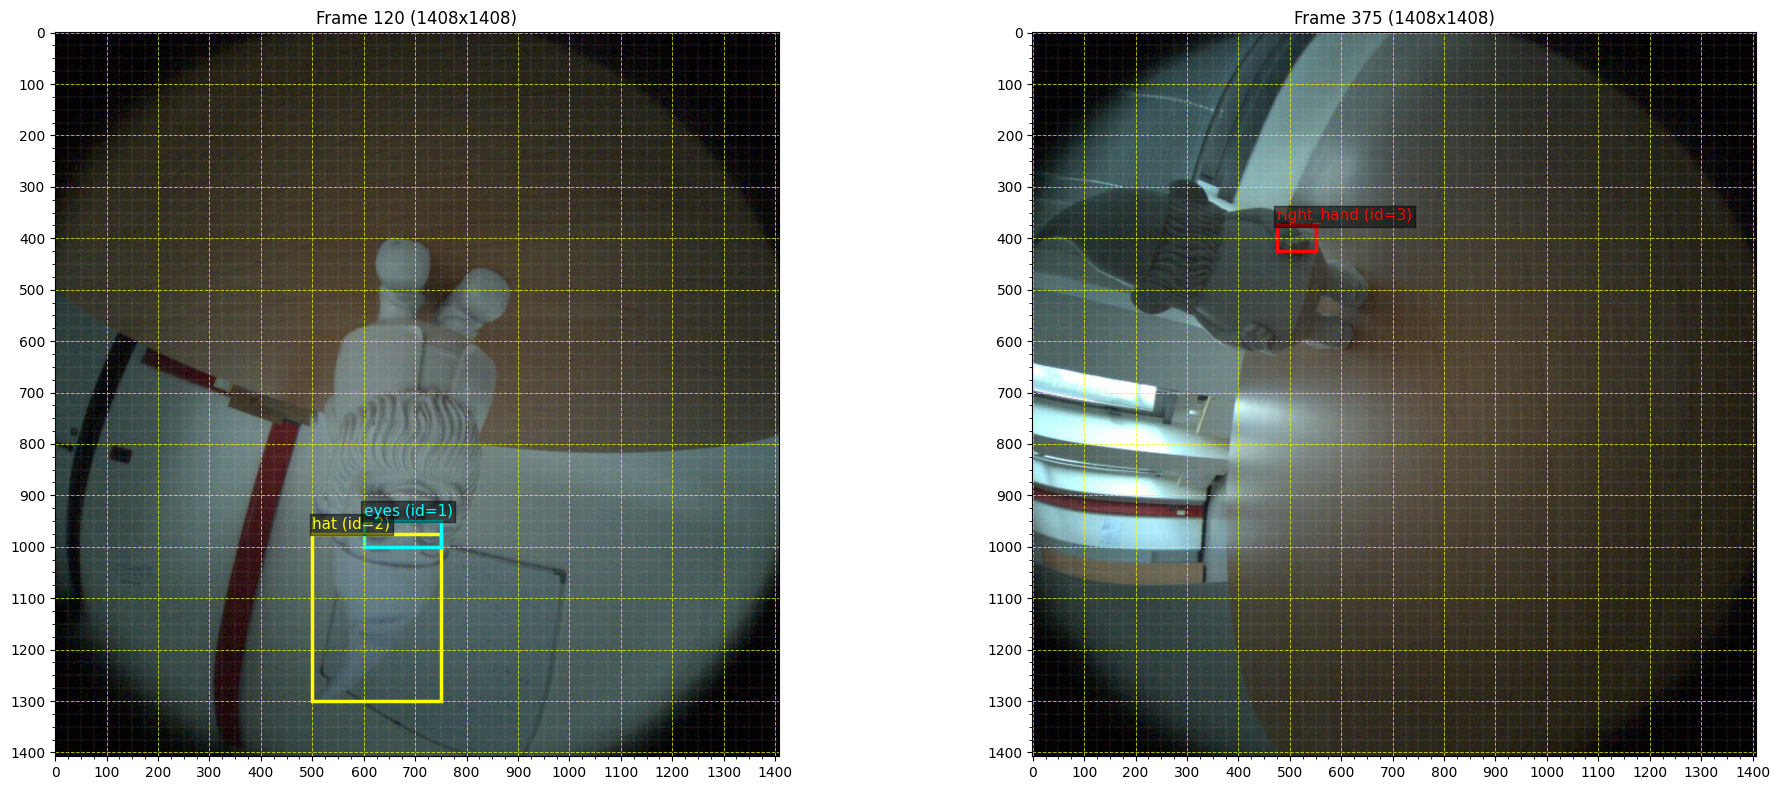

In [13]:
# Visual verification of prompt boxes on their assigned frames
import matplotlib.patches as patches

colors = {
    "eyes": "cyan",
    "hat": "yellow",
    "right_hand": "red",
}

fixed_prompt_frames = sorted(set(PROMPT_FRAME_IDX_BY_OBJECT.values()))
fig, axes = plt.subplots(1, len(fixed_prompt_frames), figsize=(10 * len(fixed_prompt_frames), 8))
if len(fixed_prompt_frames) == 1:
    axes = [axes]

for ax, frame_idx in zip(axes, fixed_prompt_frames):
    frame_rgb = np.array(Image.open(frame_files_5fps[frame_idx]).convert("RGB"))
    h, w = frame_rgb.shape[:2]

    ax.imshow(frame_rgb)
    ax.set_title(f"Frame {frame_idx} ({w}x{h})")
    ax.axis("on")

    # dense grid for precise inspection
    ax.set_xticks(np.arange(0, w + 1, 100))
    ax.set_yticks(np.arange(0, h + 1, 100))
    ax.set_xticks(np.arange(0, w + 1, 25), minor=True)
    ax.set_yticks(np.arange(0, h + 1, 25), minor=True)
    ax.grid(which="major", color="yellow", linestyle="--", linewidth=0.7, alpha=0.7)
    ax.grid(which="minor", color="white", linestyle=":", linewidth=0.35, alpha=0.45)

    # draw objects assigned to this frame
    objs_here = [name for name, idx in PROMPT_FRAME_IDX_BY_OBJECT.items() if idx == frame_idx]
    for obj_name in objs_here:
        x0, y0, x1, y1 = BOX_PROMPTS_5FPS[obj_name]
        rect = patches.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            fill=False,
            linewidth=2.5,
            edgecolor=colors.get(obj_name, "lime"),
        )
        ax.add_patch(rect)
        ax.text(
            x0,
            max(0, y0 - 10),
            f"{obj_name} (id={OBJECT_IDS[obj_name]})",
            color=colors.get(obj_name, "lime"),
            fontsize=11,
            bbox=dict(facecolor="black", alpha=0.5, pad=2),
        )

plt.tight_layout()
plt.show()

## 5.3 SAM3 Baseline Segmentation

In this section, we initialize SAM3 on the 5fps frame folder, add box prompts on fixed frames, and propagate masks across the sequence.
We will use the Small SAM3 model for the evaluation.

In [14]:
# 5.3.1 Runtime setup
import torch
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    raise RuntimeError("CUDA is required for this SAM3 run.")

SAM3_MASKS_DIR = SAM3_ROOT / "masks"
SAM3_VIS_DIR = SAM3_ROOT / "visualizations"
SAM3_MASKS_DIR.mkdir(parents=True, exist_ok=True)
SAM3_VIS_DIR.mkdir(parents=True, exist_ok=True)

SAVE_OVERLAYS = False
SAVE_EVERY_N = 1
OVERLAY_EVERY_N = 50
CLEAN_PREVIOUS_OUTPUTS = False

if CLEAN_PREVIOUS_OUTPUTS:
    for p in SAM3_MASKS_DIR.glob("*.png"):
        p.unlink()
    for p in SAM3_VIS_DIR.glob("*.jpg"):
        p.unlink()

print("DEVICE:", DEVICE)
print("Frames (5fps):", SAM3_FRAMES_DIR_5FPS)
print("Masks dir:", SAM3_MASKS_DIR)
print("Vis dir:", SAM3_VIS_DIR)

DEVICE: cuda
Frames (5fps): ..\data\outputs\segmentation\gnome\sam3\frames_5fps
Masks dir: ..\data\outputs\segmentation\gnome\sam3\masks
Vis dir: ..\data\outputs\segmentation\gnome\sam3\visualizations


### 5.3.2 GPU Cache Cleanup (Before Model Init)

This cell clears Python and CUDA caches before building the predictor.

In [15]:
# Ensure no lingering references to SAM3 state or predictor that could hold GPU memory
for v in ["inference_state"]:
    if v in globals():
        del globals()[v]
import gc, torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()
    print(
        "CUDA cache cleared | allocated:",
        f"{torch.cuda.memory_allocated() / (1024**3):.3f} GB | reserved:",
        f"{torch.cuda.memory_reserved() / (1024**3):.3f} GB"
    )
else:
    print("CUDA not available.")

In [ ]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "setuptools", "wheel"])

print("Dependency installation completed.")
print("Python executable:", sys.executable)

Dependency installation completed.
Python executable: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Scripts\python.exe


In [ ]:
import importlib.util

spec = importlib.util.find_spec("pkg_resources")
print("pkg_resources available:", spec is not None)

if spec is None:
    raise RuntimeError("pkg_resources is still missing. Restart kernel and run this check again.")

pkg_resources available: False


RuntimeError: pkg_resources is still missing. Restart kernel and run this check again.